In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, roc_auc_score
import warnings
from utils import create_temporal_features, summary_stats_user, risk_assessment
from utils import evaluate_outlier_model
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from pyod.models.ecod import ECOD
from pyod.models.iforest import IForest
import matplotlib.pyplot as plt
import seaborn as sns


# Suppress all warnings
warnings.filterwarnings("ignore")

In [2]:
# --------------------
# Load data
# --------------------
train_df = pd.read_csv(r'clean_data/cleaned_loans_train.csv')
valid_df = pd.read_csv(r'clean_data/cleaned_loans_valid.csv')
test_df = pd.read_csv(r'clean_data/cleaned_loans_test.csv')

In [3]:
valid_df["target"].value_counts()

target
0.0    4693
1.0     677
Name: count, dtype: int64

In [4]:
pd.set_option('display.max_columns', None)
train_df.head()

,index,target,CreditScore,FirstPaymentDate,FirstTimeHomebuyerFlag,MaturityDate,MSA,MI_Pct,NumberOfUnits,OccupancyStatus,OriginalCLTV,OriginalDTI,OriginalUPB,OriginalLTV,OriginalInterestRate,Channel,ProductType,PropertyState,PropertyType,PostalCode,LoanPurpose,OriginalLoanTerm,NumberOfBorrowers,SellerName,ServicerName,SuperConformingFlag,ProgramIndicator,PropertyValMethod,BalloonIndicator,0_CurrentActualUPB,0_CurrentInterestRate,0_CurrentNonInterestBearingUPB,0_EstimatedLTV,0_InterestBearingUPB,0_LoanAge,0_MonthlyReportingPeriod,0_RemainingMonthsToLegalMaturity,1_CurrentActualUPB,1_CurrentInterestRate,1_CurrentNonInterestBearingUPB,1_EstimatedLTV,1_InterestBearingUPB,1_LoanAge,1_MonthlyReportingPeriod,1_RemainingMonthsToLegalMaturity,2_CurrentActualUPB,2_CurrentInterestRate,2_CurrentNonInterestBearingUPB,2_EstimatedLTV,2_InterestBearingUPB,2_LoanAge,2_MonthlyReportingPeriod,2_RemainingMonthsToLegalMaturity,3_CurrentActualUPB,3_CurrentInterestRate,3_CurrentNonInterestBearingUPB,3_EstimatedLTV,3_InterestBearingUPB,3_LoanAge,3_MonthlyReportingPeriod,3_RemainingMonthsToLegalMaturity,4_CurrentActualUPB,4_CurrentInterestRate,4_CurrentNonInterestBearingUPB,4_EstimatedLTV,4_InterestBearingUPB,4_LoanAge,4_MonthlyReportingPeriod,4_RemainingMonthsToLegalMaturity,5_CurrentActualUPB,5_CurrentInterestRate,5_CurrentNonInterestBearingUPB,5_EstimatedLTV,5_InterestBearingUPB,5_LoanAge,5_MonthlyReportingPeriod,5_RemainingMonthsToLegalMaturity,6_CurrentActualUPB,6_CurrentInterestRate,6_CurrentNonInterestBearingUPB,6_EstimatedLTV,6_InterestBearingUPB,6_LoanAge,6_MonthlyReportingPeriod,6_RemainingMonthsToLegalMaturity,7_CurrentActualUPB,7_CurrentInterestRate,7_CurrentNonInterestBearingUPB,7_EstimatedLTV,7_InterestBearingUPB,7_LoanAge,7_MonthlyReportingPeriod,7_RemainingMonthsToLegalMaturity,8_CurrentActualUPB,8_CurrentInterestRate,8_CurrentNonInterestBearingUPB,8_EstimatedLTV,8_InterestBearingUPB,8_LoanAge,8_MonthlyReportingPeriod,8_RemainingMonthsToLegalMaturity,9_CurrentActualUPB,9_CurrentInterestRate,9_CurrentNonInterestBearingUPB,9_EstimatedLTV,9_InterestBearingUPB,9_LoanAge,9_MonthlyReportingPeriod,9_RemainingMonthsToLegalMaturity,10_CurrentActualUPB,10_CurrentInterestRate,10_CurrentNonInterestBearingUPB,10_EstimatedLTV,10_InterestBearingUPB,10_LoanAge,10_MonthlyReportingPeriod,10_RemainingMonthsToLegalMaturity,11_CurrentActualUPB,11_CurrentInterestRate,11_CurrentNonInterestBearingUPB,11_EstimatedLTV,11_InterestBearingUPB,11_LoanAge,11_MonthlyReportingPeriod,11_RemainingMonthsToLegalMaturity,12_CurrentActualUPB,12_CurrentInterestRate,12_CurrentNonInterestBearingUPB,12_EstimatedLTV,12_InterestBearingUPB,12_LoanAge,12_MonthlyReportingPeriod,12_RemainingMonthsToLegalMaturity,13_CurrentActualUPB,13_CurrentInterestRate,13_CurrentNonInterestBearingUPB,13_EstimatedLTV,13_InterestBearingUPB,13_LoanAge,13_MonthlyReportingPeriod,13_RemainingMonthsToLegalMaturity,CreditScore_is_outlier,OriginalDTI_is_outlier,EstimatedLTV_all_MissFlag
0,0.0,0.0,747,202403,N,205402,NaN,0,1,P,67,26,82000,67,8.000,R,FRM,KS,MH,67600,P,360,1,Other sellers,Other servicers,N,Unknown,2,Unknown,82000.0,8.000,0.0,67.0,82000.0,0,202402,360,82000.0,8.000,0.0,67.0,82000.0,1,202403,359,82000.0,8.000,0.0,67.0,82000.0,2,202404,358,82000.0,8.000,0.0,67.0,82000.0,3,202405,357,82000.0,8.000,0.0,67.000000,82000.0,4,202406,356,82000.0,8.000,0.0,67.000000,82000.0,5,202407,355,82000.0,8.000,0.0,67.000000,82000.0,6,202408,354,81546.88,8.000,0.0,66.629768,81546.88,7,202409,353,81488.53,8.000,0.0,66.582092,81488.53,8,202410,352,81429.79,8.000,0.0,66.534097,81429.79,9,202411,351,81370.66,8.000,0.0,66.485783,81370.66,10,202412,350,81311.13,8.000,0.0,66.437143,81311.13,11,202501,349,81251.20,8.000,0.0,66.388176,81251.20,12,202502,348,81190.87,8.000,0.0,66.338882,81190.87,13,202503,347,False,False,1
1,1.0,0.0,659,202403,N,205402,NaN,0,1,P,68,32,305000,68,7.875,R,FRM,MI,SF,49000,P,360,2,Other sellers,Other servicers,N,Unknown,2,Unknown,305000.0,7.875,0.0,67.0,305000.0,0,202402,360,305000.0,7.875,0.0,66.

In [5]:
train_df["ServicerName"].unique()

array(['Other servicers', 'NATIONSTAR MORTGAGE LLC DBA MR. COOPER',
       'LAKEVIEW LOAN SERVICING, LLC', 'PHH MORTGAGE CORPORATION',
       'U.S. BANK N.A.', 'ROCKET MORTGAGE, LLC',
       'FREEDOM MORTGAGE CORPORATION',
       'JPMORGAN CHASE BANK, NATIONAL ASSOCIATION',
       'GUARANTEED RATE, INC.', 'UNITED WHOLESALE MORTGAGE, LLC',
       'TH MSR HOLDINGS LLC', 'GUILD MORTGAGE COMPANY LLC',
       'NEW RESIDENTIAL MORTGAGE LLC', 'PENNYMAC LOAN SERVICES, LLC',
       'CMG MORTGAGE, INC.', 'PENNYMAC CORP.',
       'FLAGSTAR BANK, NATIONAL ASSOCIATION', 'CITIZENS BANK, NA',
       'AMERIHOME MORTGAGE COMPANY, LLC'], dtype=object)

## Drop columns
Drop index<br>
Drop FirstpaymentDate because only 202403 and 202402<br>
Drop MaturityDate because there is OriginalLoanTerm<br>
Drop MSA (doesnt seem that useful?)<br>
Drop PropertyState (doesnt seem that useful?)<br>
Drop SellerName<br>
Drop ServicerName<br>
Drop Postalcode

In [6]:
train_df_dropped = train_df.drop(columns=["index", "FirstPaymentDate", "MaturityDate", "MSA", "PropertyState", "SellerName", "ServicerName", "PostalCode"])
valid_df_dropped = valid_df.drop(columns=["index", "FirstPaymentDate", "MaturityDate", "MSA", "PropertyState", "SellerName", "ServicerName", "PostalCode"])
test_df_dropped = test_df.drop(columns= ["FirstPaymentDate", "MaturityDate", "MSA", "PropertyState", "SellerName", "ServicerName", "PostalCode"])

## Handle Time data

In [7]:
train_df_dropped[["0_CurrentInterestRate", "1_CurrentInterestRate", "13_CurrentInterestRate"]]

,0_CurrentInterestRate,1_CurrentInterestRate,13_CurrentInterestRate
0,8.000,8.000,8.000
1,7.875,7.875,7.875
2,7.625,7.625,7.625
3,7.250,7.250,7.250
4,7.750,7.750,7.750
...,...,...,...
30499,8.125,8.125,8.125
30500,6.125,6.125,6.125
30501,7.000,7.000,7.000
30502,5.875,5.875,5.875


In [8]:
train_df_dropped = create_temporal_features(train_df_dropped)
valid_df_dropped = create_temporal_features(valid_df_dropped)
test_df_dropped = create_temporal_features(test_df_dropped)
train_df_dropped = summary_stats_user(train_df_dropped)
valid_df_dropped = summary_stats_user(valid_df_dropped)
test_df_dropped = summary_stats_user(test_df_dropped)
train_df_dropped = risk_assessment(train_df_dropped)
valid_df_dropped = risk_assessment(valid_df_dropped)
test_df_dropped = risk_assessment(test_df_dropped)

In [9]:
train_df_dropped.head()

,target,CreditScore,FirstTimeHomebuyerFlag,MI_Pct,NumberOfUnits,OccupancyStatus,OriginalCLTV,OriginalDTI,OriginalUPB,OriginalLTV,OriginalInterestRate,Channel,ProductType,PropertyType,LoanPurpose,OriginalLoanTerm,NumberOfBorrowers,SuperConformingFlag,ProgramIndicator,PropertyValMethod,BalloonIndicator,0_CurrentActualUPB,0_CurrentInterestRate,0_CurrentNonInterestBearingUPB,0_EstimatedLTV,0_InterestBearingUPB,0_LoanAge,0_MonthlyReportingPeriod,0_RemainingMonthsToLegalMaturity,1_CurrentActualUPB,1_CurrentInterestRate,1_CurrentNonInterestBearingUPB,1_EstimatedLTV,1_InterestBearingUPB,1_LoanAge,1_MonthlyReportingPeriod,1_RemainingMonthsToLegalMaturity,2_CurrentActualUPB,2_CurrentInterestRate,2_CurrentNonInterestBearingUPB,2_EstimatedLTV,2_InterestBearingUPB,2_LoanAge,2_MonthlyReportingPeriod,2_RemainingMonthsToLegalMaturity,3_CurrentActualUPB,3_CurrentInterestRate,3_CurrentNonInterestBearingUPB,3_EstimatedLTV,3_InterestBearingUPB,3_LoanAge,3_MonthlyReportingPeriod,3_RemainingMonthsToLegalMaturity,4_CurrentActualUPB,4_CurrentInterestRate,4_CurrentNonInterestBearingUPB,4_EstimatedLTV,4_InterestBearingUPB,4_LoanAge,4_MonthlyReportingPeriod,4_RemainingMonthsToLegalMaturity,5_CurrentActualUPB,5_CurrentInterestRate,5_CurrentNonInterestBearingUPB,5_EstimatedLTV,5_InterestBearingUPB,5_LoanAge,5_MonthlyReportingPeriod,5_RemainingMonthsToLegalMaturity,6_CurrentActualUPB,6_CurrentInterestRate,6_CurrentNonInterestBearingUPB,6_EstimatedLTV,6_InterestBearingUPB,6_LoanAge,6_MonthlyReportingPeriod,6_RemainingMonthsToLegalMaturity,7_CurrentActualUPB,7_CurrentInterestRate,7_CurrentNonInterestBearingUPB,7_EstimatedLTV,7_InterestBearingUPB,7_LoanAge,7_MonthlyReportingPeriod,7_RemainingMonthsToLegalMaturity,8_CurrentActualUPB,8_CurrentInterestRate,8_CurrentNonInterestBearingUPB,8_EstimatedLTV,8_InterestBearingUPB,8_LoanAge,8_MonthlyReportingPeriod,8_RemainingMonthsToLegalMaturity,9_CurrentActualUPB,9_CurrentInterestRate,9_CurrentNonInterestBearingUPB,9_EstimatedLTV,9_InterestBearingUPB,9_LoanAge,9_MonthlyReportingPeriod,9_RemainingMonthsToLegalMaturity,10_CurrentActualUPB,10_CurrentInterestRate,10_CurrentNonInterestBearingUPB,10_EstimatedLTV,10_InterestBearingUPB,10_LoanAge,10_MonthlyReportingPeriod,10_RemainingMonthsToLegalMaturity,11_CurrentActualUPB,11_CurrentInterestRate,11_CurrentNonInterestBearingUPB,11_EstimatedLTV,11_InterestBearingUPB,11_LoanAge,11_MonthlyReportingPeriod,11_RemainingMonthsToLegalMaturity,12_CurrentActualUPB,12_CurrentInterestRate,12_CurrentNonInterestBearingUPB,12_EstimatedLTV,12_InterestBearingUPB,12_LoanAge,12_MonthlyReportingPeriod,12_RemainingMonthsToLegalMaturity,13_CurrentActualUPB,13_CurrentInterestRate,13_CurrentNonInterestBearingUPB,13_EstimatedLTV,13_InterestBearingUPB,13_LoanAge,13_MonthlyReportingPeriod,13_RemainingMonthsToLegalMaturity,CreditScore_is_outlier,OriginalDTI_is_outlier,EstimatedLTV_all_MissFlag,0_1_UPB_Diff,1_2_UPB_Diff,2_3_UPB_Diff,3_4_UPB_Diff,4_5_UPB_Diff,5_6_UPB_Diff,6_7_UPB_Diff,7_8_UPB_Diff,8_9_UPB_Diff,9_10_UPB_Diff,10_11_UPB_Diff,11_12_UPB_Diff,12_13_UPB_Diff,UPB_std,UPB_trend,UPB_range,longest_unchanged_UPB,avg_repayment_ratio,std_repayment_ratio,pct_months_late,repayment_trend_slope,DebtServiceRatio,LTV_DTI_Interaction,CreditScore_LTV_Ratio,CreditScore_DTI_Ratio,HighRiskCredit,HighLTV,HighDTI,HighInterestRate,CompositeRiskScore
0,0.0,747,N,0,1,P,67,26,82000,67,8.000,R,FRM,MH,P,360,1,N,Unknown,2,Unknown,82000.0,8.000,0.0,67.0,82000.0,0,202402,360,82000.0,8.000,0.0,67.0,82000.0,1,202403,359,82000.0,8.000,0.0,67.0,82000.0,2,202404,358,82000.0,8.000,0.0,67.0,82000.0,3,202405,357,82000.0,8.000,0.0,67.000000,82000.0,4,202406,356,82000.0,8.000,0.0,67.000000,82000.0,5,202407,355,82000.0,8.000,0.0,67.000000,82000.0,6,202408,354,81546.88,8.000,0.0,66.629768,81546.88,7,202409,353,81488.53,8.000,0.0,66.582092,81488.53,8,202410,352,81429.79,8.000,0.0,66.534097,81429.79,9,202411,351,81370.66,8.000,0.0,66.485783,81370.66,10,202412,350,81311.13,8.000,0.0,66.437143,81311.13,11,202501,349,81251.20,8.000,0.0,66.

In [28]:
boolean_cols = [
    "FirstTimeHomebuyerFlag", 
    "SuperConformingFlag", 
    "CreditScore_is_outlier", 
    "OriginalDTI_is_outlier", 
    "EstimatedLTV_all_MissFlag", 
    "HighRiskCredit", 
    "HighLTV",
    "HighDTI",
    "HighInterestRate",
]
categorical_cols = [
    "OccupancyStatus", 
    "Channel",
    "ProductType", 
    "PropertyType", 
    "LoanPurpose",
    "ProgramIndicator",
    "PropertyValMethod",
    "BalloonIndicator"
]
numeric_cols = [
    "CreditScore",
    "MI_Pct",
    "NumberOfUnits", #maybe can be in cat
    "OriginalCLTV",
    "OriginalDTI",
    "OriginalUPB",
    "OriginalLTV",
    "OriginalInterestRate",
    "OriginalLoanTerm",
    "NumberOfBorrowers",
    "0_1_UPB_Diff",
    "1_2_UPB_Diff",
    "2_3_UPB_Diff",
    "3_4_UPB_Diff",
    "4_5_UPB_Diff",
    "5_6_UPB_Diff",
    "6_7_UPB_Diff",
    "7_8_UPB_Diff",
    "8_9_UPB_Diff",
    "9_10_UPB_Diff",
    "10_11_UPB_Diff",
    "11_12_UPB_Diff",
    "12_13_UPB_Diff",
    "UPB_std",
    "UPB_trend",
    "UPB_range",
    "avg_repayment_ratio",
    "std_repayment_ratio",
    "pct_months_late",
    "repayment_trend_slope",
    "DebtServiceRatio",
    "LTV_DTI_Interaction",
    "CreditScore_LTV_Ratio",
    "CreditScore_DTI_Ratio",
    "longest_unchanged_UPB",
    "CompositeRiskScore"
]

In [29]:
from sklearn.feature_selection import VarianceThreshold

# Assumes X_train_feat is your pre-processed (numeric) data
selector = VarianceThreshold(threshold=0.01) # Threshold can be tuned
selector.fit(X_train_numeric_scaled) 

# Get the columns to keep
kept_cols = X_train_numeric.columns[selector.get_support()]
print(f"Kept {len(kept_cols)} numeric features.")

NameError: name 'X_train_numeric_scaled' is not defined

## Final filtering and preprocessing

In [30]:
X_train = train_df_dropped.drop(columns=["target"])
X_valid = valid_df_dropped.drop(columns=["target"])
y_valid = valid_df_dropped["target"].values
X_train_feat = X_train[categorical_cols + numeric_cols + boolean_cols]
X_valid_feat = X_valid[categorical_cols + numeric_cols + boolean_cols]
X_test_feat = test_df_dropped[categorical_cols + numeric_cols + boolean_cols]
for col in categorical_cols:
    X_train_feat[col] = X_train_feat[col].astype(str)
    X_valid_feat[col] = X_valid_feat[col].astype(str)
    X_test_feat[col] = X_test_feat[col].astype(str)
bool_map = {'Y': True, 'N': False}
for col in boolean_cols:
    X_train_feat[col] = X_train_feat[col].map(bool_map).astype(bool)
    X_valid_feat[col] = X_valid_feat[col].map(bool_map).astype(bool)
    X_test_feat[col] = X_test_feat[col].map(bool_map).astype(bool)

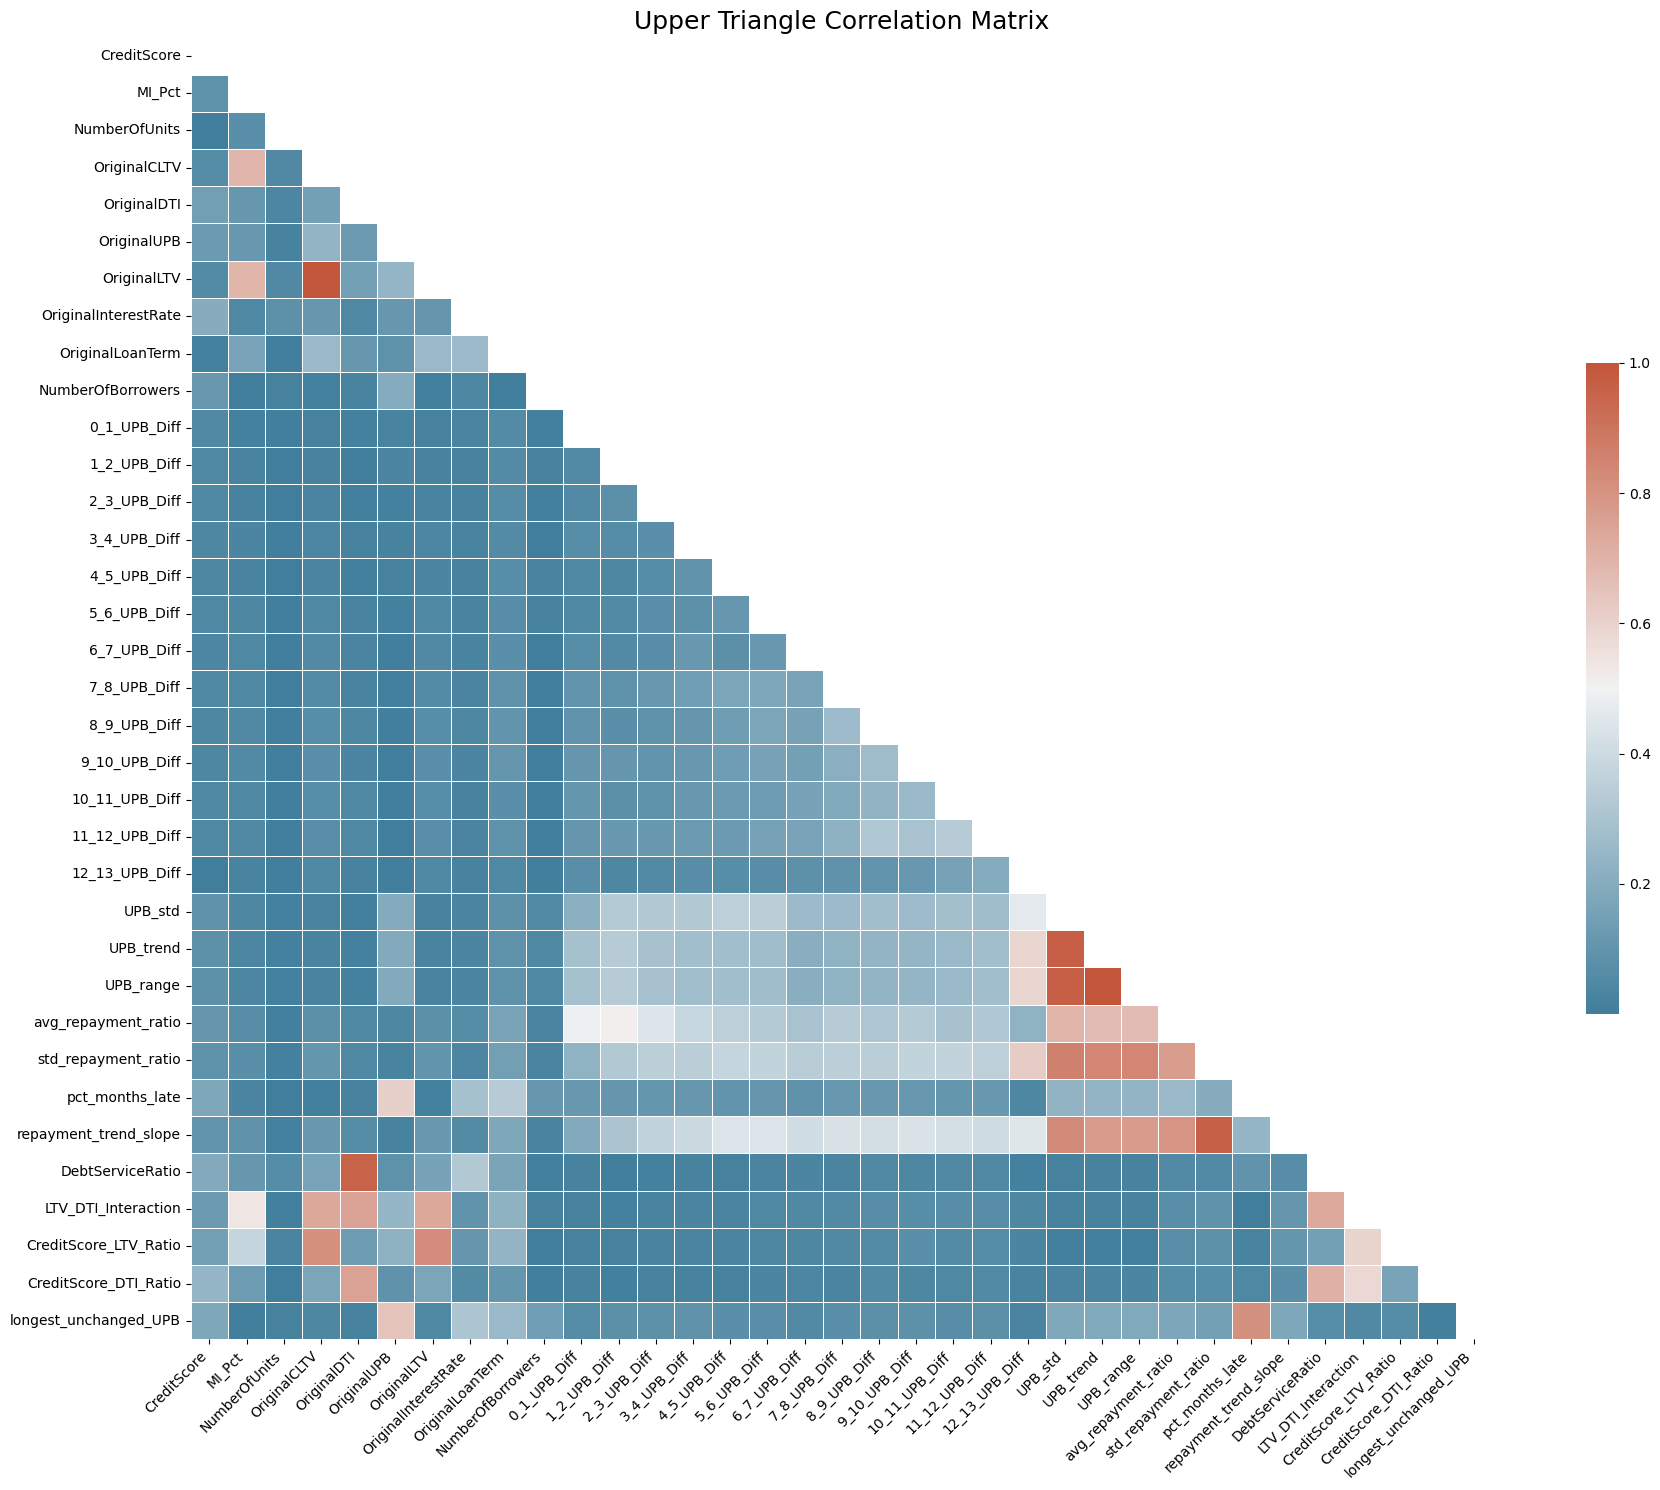

In [31]:
# --- 3. Create a Mask for the Upper Triangle ---
# This ensures we only see the upper half, avoiding redundant information.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# --- 4. Generate the Heatmap ---
# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(20, 15))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1.0, center=0.5,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Upper Triangle Correlation Matrix', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout() # Adjust layout to make room for labels
plt.show()

In [32]:
corr_matrix = X_train_feat[numeric_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Find index of feature columns with correlation greater than 0.95
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]

print(f"Features to drop due to high correlation: {to_drop}")
X_train_filtered = X_train_feat.drop(columns=to_drop)
X_valid_filtered = X_valid_feat.drop(columns=to_drop)
X_test_filtered = X_test_feat.drop(columns=to_drop)

Features to drop due to high correlation: ['OriginalLTV', 'UPB_trend', 'UPB_range', 'repayment_trend_slope', 'DebtServiceRatio']


In [33]:
X_train_filtered

,OccupancyStatus,Channel,ProductType,PropertyType,LoanPurpose,ProgramIndicator,PropertyValMethod,BalloonIndicator,CreditScore,MI_Pct,NumberOfUnits,OriginalCLTV,OriginalDTI,OriginalUPB,OriginalInterestRate,OriginalLoanTerm,NumberOfBorrowers,0_1_UPB_Diff,1_2_UPB_Diff,2_3_UPB_Diff,3_4_UPB_Diff,4_5_UPB_Diff,5_6_UPB_Diff,6_7_UPB_Diff,7_8_UPB_Diff,8_9_UPB_Diff,9_10_UPB_Diff,10_11_UPB_Diff,11_12_UPB_Diff,12_13_UPB_Diff,UPB_std,avg_repayment_ratio,std_repayment_ratio,pct_months_late,LTV_DTI_Interaction,CreditScore_LTV_Ratio,CreditScore_DTI_Ratio,longest_unchanged_UPB,CompositeRiskScore,FirstTimeHomebuyerFlag,SuperConformingFlag,CreditScore_is_outlier,OriginalDTI_is_outlier,EstimatedLTV_all_MissFlag,HighRiskCredit,HighLTV,HighDTI,HighInterestRate
0,P,R,FRM,MH,P,Unknown,2,Unknown,747,0,1,67,26,82000,8.000,360,1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.552585,0.071554,0.072084,0.072615,0.073159,0.073705,0.074251,338.358025,0.003842,0.004126,0.428571,1742,11.149254,28.730768,6,1,False,False,True,True,True,True,True,True,True
1,P,R,FRM,SF,P,Unknown,2,Unknown,659,0,1,68,32,305000,7.875,360,2,0.0,0.327869,0.000000,0.000000,0.000000,0.000000,0.236270,0.072926,0.073461,0.073997,0.074537,0.075082,0.075632,986.892356,0.005088,0.003236,0.357143,2176,9.691176,20.593749,4,1,False,False,True,True,True,True,True,True,True
2,I,R,FRM,SF,C,Unknown,2,Unknown,775,0,2,70,15,154000,7.625,360,2,0.0,0.000000,0.000000,0.649351,0.000000,0.000000,0.021556,0.098936,0.099663,0.100397,0.101141,0.101886,0.102634,697.977300,0.006235,0.004532,0.357143,1050,11.071429,51.666663,3,1,False,False,True,True,True,True,True,True,True
3,P,R,FRM,SF,P,H,2,N,815,25,1,88,49,51000,7.250,360,1,0.0,0.000000,1.960784,0.000000,0.000000,0.000000,-0.619060,0.086027,0.086619,0.000000,0.174961,0.088422,0.089039,390.097853,0.013596,0.007649,0.500000,4312,9.261364,16.632653,4,3,True,False,True,True,True,True,True,True,True
4,P,R,FRM,SF,C,Unknown,2,Unknown,772,0,1,69,41,155000,7.750,360,1,0.0,0.000000,0.000000,0.645161,0.000000,0.000000,-0.068032,0.074741,0.075278,0.000000,0.075822,0.076374,0.076920,548.918499,0.005180,0.003541,0.500000,2829,11.188406,18.829268,3,1,False,False,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30499,I,C,FRM,SF,N,Unknown,2,Unknown,709,0,1,80,32,268000,8.125,360,2,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.244337,0.068902,0.069420,0.069938,0.070461,0.070989,0.071518,684.624916,0.005987,0.002555,0.428571,2560,8.862500,22.156249,6,1,False,False,True,True,True,True,True,True,True
30500,P,R,FRM,PU,P,Unknown,2,Unknown,782,0,1,28,50,314000,6.125,360,1,0.0,0.318471,0.000000,0.000000,0.319489,0.000000,0.054276,0.101420,0.102043,0.102668,0.103298,0.103933,0.104573,1321.311201,0.006570,0.004208,0.285714,1400,27.928571,15.640000,2,1,False,False,True,True,True,True,True,True,True
30501,P,R,FRM,SF,P,H,2,Unknown,669,0,1,80,36,60000,7.000,360,1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.583967,0.085885,0.086462,0.087024,0.087621,0.088202,0.088802,273.192097,0.004213,0.004553,0.428571,2880,8.362500,18.583333,6,0,True,False,True,True,True,True,True,True,True
30502,P,R,FRM,SF,P,Unknown,2,N,741,30,1,95,41,517000,5.875,360,1,0.0,0.193798,0.000000,0.000000,0.194175,0.000000,0.192525,0.213062,0.107543,0.000000,0.108185,0.108832,0.219505,2247.566725,0.007617,0.004347,0.357143,3895,7.800000,18.073170,2,1,False,False,True,True,True,True,True,True,True


## Isolation forest (scikit learn)

In [34]:
model = IsolationForest(
    n_estimators=200,
    max_samples="auto",
    contamination="auto",
    random_state=42,
    n_jobs=-1,
)
ap, roc_auc, scores = evaluate_outlier_model(
            model, X_train_feat, X_valid_feat, y_valid, categorical_cols, numeric_cols, boolean_cols, True
)
print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

AP: 0.1300
AUC-ROC : 0.5449


In [37]:

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_cols), #PYOD dont handle spare output
        ("num", StandardScaler(with_mean=False), numeric_cols),
        ("bool", "passthrough", boolean_cols),
    ],
    sparse_threshold=1.0,
)
pipe = Pipeline([
    ("prep", preprocess), # Your ColumnTransformer
    ("clf", IsolationForest(random_state=42))
])

pipe.fit(X_train_feat)

# IsolationForest doesn't directly expose feature_importances_ after a pipeline.
# We can get them from the trained model's underlying estimators.
# This assumes the model inside the pipeline is named 'clf'.
importances = pipe.named_steps['clf'].feature_importances_
feature_names = pipe.named_steps['prep'].get_feature_names_out()

# Create a DataFrame for easy viewing
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Feature Importances from Isolation Forest:")
print(importance_df.head(20))

# --- Now, select the top N features based on this ranking ---
top_features = importance_df['feature'].head(30).tolist()

AttributeError: 'IsolationForest' object has no attribute 'feature_importances_'

## LOF (scikit learn)

In [35]:
lof = LocalOutlierFactor(n_neighbors=20, novelty=True)
ap, roc_auc, scores = evaluate_outlier_model(
            lof, X_train_feat, X_valid_feat, y_valid, categorical_cols, numeric_cols, boolean_cols, True
)
print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

AP: 0.2314
AUC-ROC : 0.6499


In [36]:
lof = LocalOutlierFactor(n_neighbors=20, novelty=True)
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_cols), 
        ("num", StandardScaler(with_mean=False), numeric_cols),
        ("bool", "passthrough", boolean_cols),
    ],
    sparse_threshold=1.0,
)
pipe = Pipeline([("prep", preprocess), ("clf", lof)])
pipe.fit(X_train_feat)

# Score validation
scores_normal = pipe["clf"].score_samples(pipe["prep"].transform(X_valid_feat))
raw_anom = -scores_normal  # invert: higher = more anomalous

# Normalize to [0,1]
min_v, max_v = np.min(raw_anom), np.max(raw_anom)
anom_score = (raw_anom - min_v) / (max_v - min_v + 1e-12)

# Evaluation
ap = average_precision_score(y_valid, anom_score)
roc_auc = roc_auc_score(y_valid, anom_score)
print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

AP: 0.2371
AUC-ROC : 0.6513


In [47]:
scores_normal = pipe["clf"].score_samples(pipe["prep"].transform(X_test_feat))
raw_anom = -scores_normal  # invert: higher = more anomalous
min_v, max_v = np.min(raw_anom), np.max(raw_anom)
anom_score = (raw_anom - min_v) / (max_v - min_v + 1e-12)


In [48]:
anom_score

array([0.04689876, 0.01227855, 0.06131705, ..., 0.10179783, 0.11210975,
       0.2733603 ], shape=(13426,))

In [45]:
test_df_dropped

,CreditScore,FirstTimeHomebuyerFlag,MI_Pct,NumberOfUnits,OccupancyStatus,OriginalCLTV,OriginalDTI,OriginalUPB,OriginalLTV,OriginalInterestRate,Channel,ProductType,PropertyType,LoanPurpose,OriginalLoanTerm,NumberOfBorrowers,SuperConformingFlag,ProgramIndicator,PropertyValMethod,BalloonIndicator,0_CurrentActualUPB,0_CurrentInterestRate,0_CurrentNonInterestBearingUPB,0_EstimatedLTV,0_InterestBearingUPB,0_LoanAge,0_MonthlyReportingPeriod,0_RemainingMonthsToLegalMaturity,1_CurrentActualUPB,1_CurrentInterestRate,1_CurrentNonInterestBearingUPB,1_EstimatedLTV,1_InterestBearingUPB,1_LoanAge,1_MonthlyReportingPeriod,1_RemainingMonthsToLegalMaturity,2_CurrentActualUPB,2_CurrentInterestRate,2_CurrentNonInterestBearingUPB,2_EstimatedLTV,2_InterestBearingUPB,2_LoanAge,2_MonthlyReportingPeriod,2_RemainingMonthsToLegalMaturity,3_CurrentActualUPB,3_CurrentInterestRate,3_CurrentNonInterestBearingUPB,3_EstimatedLTV,3_InterestBearingUPB,3_LoanAge,3_MonthlyReportingPeriod,3_RemainingMonthsToLegalMaturity,4_CurrentActualUPB,4_CurrentInterestRate,4_CurrentNonInterestBearingUPB,4_EstimatedLTV,4_InterestBearingUPB,4_LoanAge,4_MonthlyReportingPeriod,4_RemainingMonthsToLegalMaturity,5_CurrentActualUPB,5_CurrentInterestRate,5_CurrentNonInterestBearingUPB,5_EstimatedLTV,5_InterestBearingUPB,5_LoanAge,5_MonthlyReportingPeriod,5_RemainingMonthsToLegalMaturity,6_CurrentActualUPB,6_CurrentInterestRate,6_CurrentNonInterestBearingUPB,6_EstimatedLTV,6_InterestBearingUPB,6_LoanAge,6_MonthlyReportingPeriod,6_RemainingMonthsToLegalMaturity,7_CurrentActualUPB,7_CurrentInterestRate,7_CurrentNonInterestBearingUPB,7_EstimatedLTV,7_InterestBearingUPB,7_LoanAge,7_MonthlyReportingPeriod,7_RemainingMonthsToLegalMaturity,8_CurrentActualUPB,8_CurrentInterestRate,8_CurrentNonInterestBearingUPB,8_EstimatedLTV,8_InterestBearingUPB,8_LoanAge,8_MonthlyReportingPeriod,8_RemainingMonthsToLegalMaturity,9_CurrentActualUPB,9_CurrentInterestRate,9_CurrentNonInterestBearingUPB,9_EstimatedLTV,9_InterestBearingUPB,9_LoanAge,9_MonthlyReportingPeriod,9_RemainingMonthsToLegalMaturity,10_CurrentActualUPB,10_CurrentInterestRate,10_CurrentNonInterestBearingUPB,10_EstimatedLTV,10_InterestBearingUPB,10_LoanAge,10_MonthlyReportingPeriod,10_RemainingMonthsToLegalMaturity,11_CurrentActualUPB,11_CurrentInterestRate,11_CurrentNonInterestBearingUPB,11_EstimatedLTV,11_InterestBearingUPB,11_LoanAge,11_MonthlyReportingPeriod,11_RemainingMonthsToLegalMaturity,12_CurrentActualUPB,12_CurrentInterestRate,12_CurrentNonInterestBearingUPB,12_EstimatedLTV,12_InterestBearingUPB,12_LoanAge,12_MonthlyReportingPeriod,12_RemainingMonthsToLegalMaturity,13_CurrentActualUPB,13_CurrentInterestRate,13_CurrentNonInterestBearingUPB,13_EstimatedLTV,13_InterestBearingUPB,13_LoanAge,13_MonthlyReportingPeriod,13_RemainingMonthsToLegalMaturity,Id,CreditScore_is_outlier,OriginalDTI_is_outlier,EstimatedLTV_all_MissFlag,0_1_UPB_Diff,1_2_UPB_Diff,2_3_UPB_Diff,3_4_UPB_Diff,4_5_UPB_Diff,5_6_UPB_Diff,6_7_UPB_Diff,7_8_UPB_Diff,8_9_UPB_Diff,9_10_UPB_Diff,10_11_UPB_Diff,11_12_UPB_Diff,12_13_UPB_Diff,UPB_std,UPB_trend,UPB_range,avg_repayment_ratio,std_repayment_ratio,pct_months_late,repayment_trend_slope,DebtServiceRatio,LTV_DTI_Interaction,CreditScore_LTV_Ratio,CreditScore_DTI_Ratio,HighRiskCredit,HighLTV,HighDTI,HighInterestRate,CompositeRiskScore
0,773,N,0,1,I,80,20,174000,80,7.624,B,FRM,SF,P,360,2,N,Unknown,2,Unknown,174000.0,7.624,0.0,82.000000,174000.0,0,202402,360,174000.0,7.624,0.0,77.0,174000.0,1,202403,359,174000.0,7.624,0.0,76.0,174000.0,2,202404,358,174000.0,7.624,0.0,74.0,174000.0,3,202405,357,174000.0,7.624,0.0,73.0,174000.0,4,202406,356,174000.0,7.624,0.0,70.0,174000.0,5,202407,355,174000.0,7.624,0.0,70.0,174000.0,6,202408,354,173499.23,7.624,0.0,70.0,173499.23,7,202409,353,173367.26,7.624,0.0,70.0,173367.26,8,202410,352,173234.45,7.624,0.0,65.0,173234.45,9,202411,351,173100.80,7.624,0.0,63.0,173100.80,10,202412,350,172966.30,7.624,0.0,63.0,172966.30,11,202501,349,172830.94,7.624,0.0,62.0,172830.94,12,202502,348,172694.72,7.6

In [49]:
x_test_final = test_df_dropped[["Id"]]
x_test_final["target"]= anom_score

In [51]:
x_test_final.to_csv("output.csv", index=False)

In [37]:
X_test_feat

,OccupancyStatus,Channel,ProductType,PropertyType,LoanPurpose,ProgramIndicator,PropertyValMethod,BalloonIndicator,CreditScore,MI_Pct,NumberOfUnits,OriginalCLTV,OriginalDTI,OriginalUPB,OriginalLTV,OriginalInterestRate,OriginalLoanTerm,NumberOfBorrowers,0_1_UPB_Diff,1_2_UPB_Diff,2_3_UPB_Diff,3_4_UPB_Diff,4_5_UPB_Diff,5_6_UPB_Diff,6_7_UPB_Diff,7_8_UPB_Diff,8_9_UPB_Diff,9_10_UPB_Diff,10_11_UPB_Diff,11_12_UPB_Diff,12_13_UPB_Diff,UPB_std,UPB_trend,UPB_range,avg_repayment_ratio,std_repayment_ratio,pct_months_late,repayment_trend_slope,DebtServiceRatio,LTV_DTI_Interaction,CreditScore_LTV_Ratio,CreditScore_DTI_Ratio,FirstTimeHomebuyerFlag,SuperConformingFlag,CreditScore_is_outlier,OriginalDTI_is_outlier,EstimatedLTV_all_MissFlag,HighRiskCredit,HighLTV,HighDTI,HighInterestRate,CompositeRiskScore
0,I,B,FRM,SF,P,Unknown,2,Unknown,773,0,1,80,20,174000,80,7.624,360,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.287799,0.076064,0.076606,0.077150,0.077700,0.078258,0.078817,507.185140,-1305.28,1305.28,0.002589,0.002915,0.428571,0.000652,1.52480,1600,9.662500,38.649998,False,False,True,True,True,True,True,True,True,True
1,P,C,FRM,SF,P,Unknown,2,N,801,30,1,95,40,314000,95,6.990,360,1,0.318471,0.000000,0.000000,0.319489,0.000000,0.000000,0.107106,0.086044,0.086619,0.087199,0.087783,0.000000,0.177260,1139.548133,-3966.79,3966.79,0.006995,0.003629,0.357143,0.000850,2.79600,3800,8.431579,20.024999,True,False,True,True,True,True,True,True,True,True
2,P,C,FRM,PU,P,Unknown,2,Unknown,777,0,1,45,41,500000,45,6.625,360,2,0.200000,0.000000,0.200401,0.000000,0.200803,0.201207,0.112925,0.094120,0.114931,0.095472,0.197320,0.198802,0.200298,2791.538435,-9007.38,9007.38,0.008331,0.005583,0.142857,0.001327,2.71625,1845,17.266667,18.951219,False,False,True,True,True,True,True,True,True,True
3,P,R,FRM,SF,P,Unknown,2,N,816,25,1,87,35,595000,87,6.500,360,1,0.000000,0.336700,0.168919,0.169205,0.338983,0.170068,0.202780,0.227661,0.229417,0.231190,0.232980,0.234791,0.236618,5441.246796,-16301.45,16301.45,0.014597,0.009145,0.071429,0.002182,2.27500,3045,9.379310,23.314285,False,False,True,True,True,True,True,True,True,True
4,P,C,FRM,SF,P,H,2,Unknown,731,0,1,80,47,220000,80,7.375,360,1,0.000000,0.454545,0.000000,0.456621,0.000000,0.458716,-0.119055,0.084811,0.207565,0.124026,0.160274,4.014873,1.766865,4716.333700,-16327.70,16327.70,0.017751,0.021438,0.285714,0.004060,3.46625,3760,9.137500,15.553191,False,False,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13421,P,R,FRM,PU,P,Unknown,2,N,726,30,1,95,49,299000,95,6.625,360,2,0.000000,0.000000,0.334448,0.000000,0.000000,0.000000,0.211087,0.092272,0.092869,0.093467,0.094071,0.094679,0.095292,1121.904000,-3298.28,3298.28,0.005069,0.003752,0.357143,0.000883,3.24625,4655,7.642105,14.816326,False,False,True,True,True,True,True,True,True,True
13422,P,B,FRM,SF,P,Unknown,4,Unknown,810,0,1,66,24,142000,66,5.964,360,1,0.000000,0.000000,0.000000,0.704225,0.000000,0.000000,0.087631,0.116208,0.116926,0.117646,0.118369,0.119094,0.119829,756.603298,-2118.13,2118.13,0.007209,0.005328,0.357143,0.001232,1.43136,1584,12.272727,33.749999,False,False,True,True,True,True,True,True,True,True
13423,P,B,FRM,SF,P,Unknown,2,N,640,35,1,97,29,131000,97,6.875,360,2,0.000000,0.000000,0.000000,0.000000,0.763359,0.000000,-0.128092,0.087964,0.088549,0.089136,0.089724,0.090321,0.090919,595.318428,-1530.41,1530.41,0.005595,0.004544,0.428571,0.001012,1.99375,2813,6.597938,22.068965,True,False,True,True,True,True,True,True,True,True
13424,P,C,FRM,CO,P,Unknown,4,Unknown,790,0,1,60,39,219000,60,7.125,360,1,0.000000,0.456621,0.000000,0.000000,0.000000,0.000000,0.221702,0.084559,0.000000,0.085137,0.085716,0.097819,0.174441,766.713634,-2628.73,2628.73,0.006063,0.003501,0.428571,0.000803,2.77875,2340,13.166667,20.256410,False,False,True,True,True,True,Tru

## OneClassSVM (scikit learn)

In [22]:
osvm  = OneClassSVM(
    kernel="rbf",     # RBF works well for non-linear anomalies
    nu=0.05,          # Upper bound on fraction of anomalies in training set
    gamma="scale"     # Kernel coefficient (can tune)
)
ap, roc_auc, scores = evaluate_outlier_model(
            osvm, X_train_feat, X_valid_feat, y_valid, categorical_cols, numeric_cols, boolean_cols, True
)
print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

AP: 0.1938
AUC-ROC : 0.6586


## PYOD module 

### Probabilistic model

In [23]:
ecod = ECOD()
ap, roc_auc, scores = evaluate_outlier_model(
    ecod, X_train_feat, X_valid_feat, y_valid, categorical_cols, numeric_cols, boolean_cols, sparse_output=False, ispyod=True
)
print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

AP: 0.1843
AUC-ROC : 0.6476


In [24]:
from pyod.models.copod import COPOD

copod = COPOD()
ap, roc_auc, scores = evaluate_outlier_model(
    copod, X_train_feat, X_valid_feat, y_valid, categorical_cols, numeric_cols, boolean_cols, sparse_output=False, ispyod=True
)
print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

AP: 0.1435
AUC-ROC : 0.5906


In [25]:
from pyod.models.copod import COPOD
from pyod.models.abod import ABOD
from pyod.models.qmcd import QMCD
from pyod.models.kde import KDE
from pyod.models.sampling import Sampling
from pyod.models.gmm import GMM

# Define all models with their configurations
models = [
    ("COPOD", COPOD()),
    ("ABOD", ABOD()),
    ("FastABOD", ABOD(method='fast')),
    ("QMCD", QMCD()),
    ("KDE", KDE()),
    ("Sampling", Sampling()),
    ("GMM", GMM())
]

# Evaluate all models
results = {}
for name, model in models:
    ap, roc_auc, scores = evaluate_outlier_model(
        model, X_train_feat, X_valid_feat, y_valid, categorical_cols, numeric_cols, boolean_cols, sparse_output=False, ispyod=True
    )
    results[name] = {'AP': ap, 'AUC-ROC': roc_auc}
    print(f"{name} - AP: {ap:.4f}, AUC-ROC: {roc_auc:.4f}")

# Print summary
print("\n=== Summary ===")
for name, metrics in results.items():
    print(f"{name}: AP={metrics['AP']:.4f}, AUC-ROC={metrics['AUC-ROC']:.4f}")

COPOD - AP: 0.1435, AUC-ROC: 0.5906
ABOD - AP: 0.1612, AUC-ROC: 0.6016
FastABOD - AP: 0.1612, AUC-ROC: 0.6016
QMCD - AP: 0.1392, AUC-ROC: 0.5715
KDE - AP: 0.1506, AUC-ROC: 0.5899
Sampling - AP: 0.1317, AUC-ROC: 0.5354
GMM - AP: 0.1668, AUC-ROC: 0.5962

=== Summary ===
COPOD: AP=0.1435, AUC-ROC=0.5906
ABOD: AP=0.1612, AUC-ROC=0.6016
FastABOD: AP=0.1612, AUC-ROC=0.6016
QMCD: AP=0.1392, AUC-ROC=0.5715
KDE: AP=0.1506, AUC-ROC=0.5899
Sampling: AP=0.1317, AUC-ROC=0.5354
GMM: AP=0.1668, AUC-ROC=0.5962


### Linear model

In [26]:
# Linear Models
from pyod.models.mcd import MCD
from pyod.models.cd import CD
from pyod.models.ocsvm import OCSVM


# MCD: Minimum Covariance Determinant (1999)
mcd = MCD()
ap, roc_auc, scores = evaluate_outlier_model(
    mcd, X_train_feat, X_valid_feat, y_valid, categorical_cols, numeric_cols, boolean_cols, sparse_output=False, ispyod=True
)
print(f"MCD - AP: {ap:.4f}, AUC-ROC: {roc_auc:.4f}")

# CD: Cook's distance for outlier detection (1977)
cd = CD()
ap, roc_auc, scores = evaluate_outlier_model(
    cd, X_train_feat, X_valid_feat, y_valid, categorical_cols, numeric_cols, boolean_cols, sparse_output=False, ispyod=True
)
print(f"CD - AP: {ap:.4f}, AUC-ROC: {roc_auc:.4f}")

# OCSVM: One-Class Support Vector Machines (2001)
ocsvm = OCSVM()
ap, roc_auc, scores = evaluate_outlier_model(
    ocsvm, X_train_feat, X_valid_feat, y_valid, categorical_cols, numeric_cols, boolean_cols, sparse_output=False, ispyod=True
)
print(f"OCSVM - AP: {ap:.4f}, AUC-ROC: {roc_auc:.4f}")


MCD - AP: 0.1477, AUC-ROC: 0.6156
CD - AP: 0.1330, AUC-ROC: 0.5436
OCSVM - AP: 0.1510, AUC-ROC: 0.6033


In [27]:
iforest = IForest(n_estimators=200, contamination =0.15, bootstrap=True)
ap, roc_auc, scores = evaluate_outlier_model(
    iforest, X_train_feat, X_valid_feat, y_valid, categorical_cols, numeric_cols, boolean_cols, sparse_output=False, ispyod=True
)
print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

AP: 0.1313
AUC-ROC : 0.5483


Corpula Based Outlier Detector

In [28]:
from pyod.models.suod import SUOD

suod = SUOD()
ap, roc_auc, scores = evaluate_outlier_model(
    suod , X_train_feat, X_valid_feat, y_valid, categorical_cols, numeric_cols, boolean_cols, sparse_output=False, ispyod=True
)
print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

RandomForestRegressor()



[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   10.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  4.0min finished



AP: 0.1394
AUC-ROC : 0.5741


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.0s finished


In [29]:
from pyod.models.loda import LODA

loda = LODA()
ap, roc_auc, scores = evaluate_outlier_model(
    loda , X_train_feat, X_valid_feat, y_valid, categorical_cols, numeric_cols, boolean_cols, sparse_output=False, ispyod=True
)
print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

AP: 0.1535
AUC-ROC : 0.5828


In [30]:
from pyod.models.dif import DIF

dif = DIF()
ap, roc_auc, scores = evaluate_outlier_model(
    dif , X_train_feat, X_valid_feat, y_valid, categorical_cols, numeric_cols, boolean_cols, sparse_output=False, ispyod=True
)
print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

AP: 0.1359
AUC-ROC : 0.5385


In [31]:
from pyod.models.inne import INNE

inne = INNE()
ap, roc_auc, scores = evaluate_outlier_model(
    inne , X_train_feat, X_valid_feat, y_valid, categorical_cols, numeric_cols, boolean_cols, sparse_output=False, ispyod=True
)
print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

AP: 0.1600
AUC-ROC : 0.6132


In [24]:
pyod_models = [ECOD(),COPOD(), ABOD(), ABOD(method='fast'), QMCD(), KDE(), Sampling, GMM(), MCD(), CD, IForest(n_estimators=200, contamination =0.15, bootstrap=True), LODA()]

# Try using PCA on numerical cols

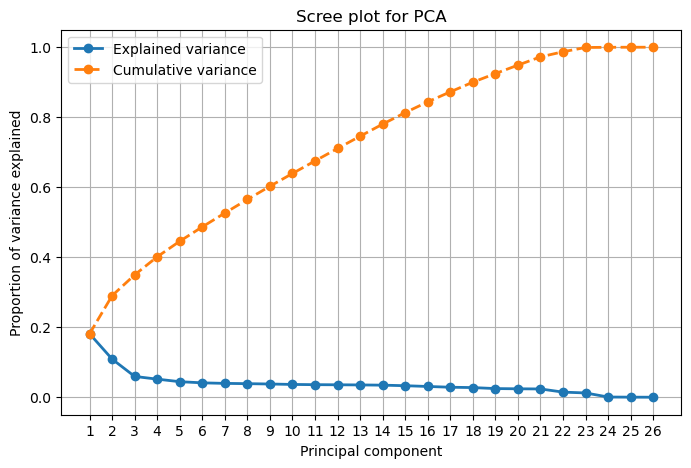

In [19]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

scaler_test = StandardScaler()
X_train_feat_numeric_scaled = pd.DataFrame(
    scaler_test.fit_transform(X_train_feat[numeric_cols]),
    columns=numeric_cols,
    index=X_train_feat.index
)


pca_full = PCA()
pca_full.fit_transform(X_train_feat_numeric_scaled)
# Scree plot and cumulative explained variance
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(evr) + 1), evr, 'o-', linewidth=2, label='Explained variance')
plt.plot(range(1, len(evr) + 1), cum, 'o--', linewidth=2, label='Cumulative variance')
plt.xticks(range(1, len(evr) + 1))
plt.xlabel('Principal component')
plt.ylabel('Proportion of variance explained')
plt.title('Scree plot for PCA')
plt.grid(True)
plt.legend()
plt.show()

In [20]:
X_valid_feat_numeric_scaled = pd.DataFrame(
    scaler_test.transform(X_valid_feat[numeric_cols]),
    columns=numeric_cols,
    index=X_valid_feat.index
)


In [21]:
pca_final = PCA(n_components=18)
X_train_numeric_reduced = pca_final.fit_transform(X_train_feat_numeric_scaled)
total_kept = pca_final.explained_variance_ratio_.sum()
print(f"\nOriginal dimensionality: {X_train_feat_numeric_scaled.shape[1]}")
print(f"Reduced dimensionality: {X_train_numeric_reduced.shape[1]}")
print(f"Total variance kept: {total_kept*100:.2f}%")


Original dimensionality: 26
Reduced dimensionality: 18
Total variance kept: 90.01%


In [22]:
X_valid_numeric_reduced = pca_final.transform(X_valid_feat_numeric_scaled)


In [23]:
X_train_numeric_reduced_df = pd.DataFrame(X_train_numeric_reduced)
X_valid_numeric_reduced_df = pd.DataFrame(X_valid_numeric_reduced)

In [24]:
X_train_pca_feat = pd.concat([X_train_numeric_reduced_df, X_train_feat[categorical_cols + boolean_cols]],axis=1)
X_valid_pca_feat = pd.concat([X_valid_numeric_reduced_df, X_valid_feat[categorical_cols + boolean_cols]],axis=1)
X_train_pca_feat.columns = X_train_pca_feat.columns.astype(str)
X_valid_pca_feat.columns = X_valid_pca_feat.columns.astype(str)

In [25]:
X_train_pca_feat["0"]

0       -0.617053
1       -0.607159
2       -0.452651
3       -0.831344
4       -0.598961
           ...   
30499   -0.710983
30500   -0.008216
30501   -0.794061
30502   -0.602859
30503   -0.170600
Name: 0, Length: 30504, dtype: float64

In [26]:
pca_cols = [f"{i}" for i in range(18)] 

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_cols),
        ("pca", "passthrough", pca_cols),  # already scaled and transformed
        ("bool", "passthrough", boolean_cols),  # make sure these are float
    ],
    sparse_threshold=1.0,
)

# --------------------
# Baseline Model: Isolation Forest
# --------------------
model = IsolationForest(
    n_estimators=200,
    max_samples="auto",
    contamination="auto",
    random_state=42,
    n_jobs=-1,
)

pipe = Pipeline([("prep", preprocess), ("clf", model)])

# Train on normal only
pipe.fit(X_train_pca_feat)

# Score validation
# IsolationForest: higher score_samples = more normal
scores_normal = pipe["clf"].score_samples(pipe["prep"].transform(X_valid_pca_feat))
raw_anom = -scores_normal  # invert: higher = more anomalous

# Normalize to [0,1]
min_v, max_v = np.min(raw_anom), np.max(raw_anom)
anom_score = (raw_anom - min_v) / (max_v - min_v + 1e-12)

# --------------------
# Evaluation
# --------------------
ap = average_precision_score(y_valid, anom_score)
roc_auc = roc_auc_score(y_valid, anom_score)

print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")


AP: 0.1258
AUC-ROC : 0.5169


In [27]:
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=20, novelty=True)
pipe_lof = Pipeline([("prep", preprocess), ("clf", lof)])
pipe_lof.fit(X_train_pca_feat)

# Score validation
# ILocal Outlier Factor: higher score_samples = more normal
scores_normal = pipe_lof["clf"].score_samples(pipe_lof["prep"].transform(X_valid_pca_feat))
raw_anom = -scores_normal  # invert: higher = more anomalous

# Normalize to [0,1]
min_v, max_v = np.min(raw_anom), np.max(raw_anom)
anom_score = (raw_anom - min_v) / (max_v - min_v + 1e-12)

# --------------------
# Evaluation
# --------------------
ap = average_precision_score(y_valid, anom_score)
roc_auc = roc_auc_score(y_valid, anom_score)

print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

AP: 0.1370
AUC-ROC : 0.5491


In [28]:
from sklearn.svm import OneClassSVM

model = OneClassSVM(
    kernel="rbf",     # RBF works well for non-linear anomalies
    nu=0.05,          # Upper bound on fraction of anomalies in training set
    gamma="scale"     # Kernel coefficient (can tune)
)


pipe = Pipeline([("prep", preprocess), ("clf", model)])

# Train on normal only
pipe.fit(X_train_pca_feat)

# Score validation
# OneClassSVM: higher score_samples = more normal
scores_normal = pipe["clf"].score_samples(pipe["prep"].transform(X_valid_pca_feat))
raw_anom = -scores_normal  # invert: higher = more anomalous

# Normalize to [0,1]
min_v, max_v = np.min(raw_anom), np.max(raw_anom)
anom_score = (raw_anom - min_v) / (max_v - min_v + 1e-12)

# --------------------
# Evaluation
# --------------------
ap = average_precision_score(y_valid, anom_score)
roc_auc = roc_auc_score(y_valid, anom_score)

print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

# # Sample Output CSV
# out_df = pd.DataFrame({"index": process_ids_valid, "anomaly_score": anom_score})
# out_df.to_csv("valid_pred.csv", index=False)
# print("Wrote valid_pred.csv")

AP: 0.1408
AUC-ROC : 0.5563


In [29]:
import numpy
numpy.__version__


'2.3.1'

In [30]:
from pyod.models.ecod import ECOD

In [31]:
from pyod.utils.example import visualize

In [32]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("pca", "passthrough", pca_cols),  # already scaled and transformed
        ("bool", "passthrough", boolean_cols),  # make sure these are float
    ],
    sparse_threshold=1.0,
)
clf = ECOD(contamination=0.15)
pipe_lof = Pipeline([("prep", preprocess), ("clf", clf)])
pipe_lof.fit(X_train_pca_feat)

# Score validation
# ECOD: higher score_samples = more abnormal
scores_normal = pipe_lof["clf"].decision_function(pipe_lof["prep"].transform(X_valid_pca_feat))

# Normalize to [0,1]
min_v, max_v = np.min(scores_normal), np.max(scores_normal)
anom_score = (scores_normal - min_v) / (max_v - min_v + 1e-12)

# --------------------
# Evaluation
# --------------------
ap = average_precision_score(y_valid, anom_score)
roc_auc = roc_auc_score(y_valid, anom_score)

print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

AP: 0.1340
AUC-ROC : 0.5452


In [33]:
from pyod.models.iforest import IForest

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("pca", "passthrough", pca_cols),  # already scaled and transformed
        ("bool", "passthrough", boolean_cols),  # make sure these are float
    ],
    sparse_threshold=1.0,
)
clf = IForest(n_estimators=200, contamination =0.15, bootstrap=True )
pipe_lof = Pipeline([("prep", preprocess), ("clf", clf)])
pipe_lof.fit(X_train_pca_feat)

# Score validation
# IForest: higher score_samples = more normal
scores_normal = pipe_lof["clf"].decision_function(pipe_lof["prep"].transform(X_valid_pca_feat))
raw_anom = scores_normal  # invert: higher = more anomalous

# Normalize to [0,1]
min_v, max_v = np.min(raw_anom), np.max(raw_anom)
anom_score = (raw_anom - min_v) / (max_v - min_v + 1e-12)

# --------------------
# Evaluation
# --------------------
ap = average_precision_score(y_valid, anom_score)
roc_auc = roc_auc_score(y_valid, anom_score)

print(f"AP: {ap:.4f}")
print(f"AUC-ROC : {roc_auc:.4f}")

AP: 0.1276
AUC-ROC : 0.5207


In [34]:
scores_normal[150]

np.float64(0.0346211343825899)

In [35]:
X_valid_pca_feat

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,OccupancyStatus,Channel,ProductType,PropertyType,LoanPurpose,ProgramIndicator,PropertyValMethod,BalloonIndicator,FirstTimeHomebuyerFlag,SuperConformingFlag,CreditScore_is_outlier,OriginalDTI_is_outlier
0,-0.582399,-0.438619,0.066948,0.163971,-0.848443,0.814369,0.311264,0.532344,-0.397957,-0.252309,-0.494955,-0.842456,0.192909,-0.109763,0.116616,-0.077021,-0.025237,-0.051049,P,R,FRM,SF,C,Unknown,2,Unknown,False,False,True,True
1,-0.554280,1.822308,0.092711,-0.720692,0.030293,0.903347,-0.315776,0.182077,-0.285490,-0.198247,-0.467845,-0.329030,0.223571,-0.017726,0.097392,0.032774,0.118732,-0.027677,P,R,FRM,SF,P,Unknown,2,N,False,False,True,True
2,-0.143571,-3.358062,-0.915954,1.237869,0.829283,-0.332576,0.028798,-0.125545,0.216249,0.082262,-0.484138,-0.554967,0.393789,-0.030007,0.029918,0.049380,-0.030787,0.027492,P,R,FRM,PU,N,Unknown,2,Unknown,False,False,True,True
3,-0.489108,-0.982060,-0.129914,0.447190,-0.687537,0.754494,0.143748,0.649165,-0.344119,0.018865,-0.673159,-0.813200,0.270995,0.146072,0.136271,-0.045916,-0.005801,-0.025054,P,R,FRM,SF,P,Unknown,1,Unknown,False,False,True,True
4,-0.958082,1.350804,0.881780,0.824250,-1.769210,-0.258044,0.364690,-0.689038,0.470864,0.256948,0.518265,0.333718,-0.330629,0.108015,0.177744,-0.078818,0.075912,0.041754,P,R,FRM,SF,P,H,2,N,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5365,-0.898569,1.102717,0.638337,0.327132,-0.828000,-0.776453,0.959838,1.499671,-0.697044,-0.254059,0.138449,-0.021922,-0.116551,-0.125667,-0.038262,-0.182834,-0.181400,0.154145,P,R,FRM,SF,P,H,2,N,True,False,True,True
5366,-0.559206,-0.882733,-0.382390,1.282175,-0.012561,3.358614,-0.469552,1.107577,-0.409900,-0.038634,1.584102,1.589782,-0.535041,-0.142064,-0.075037,-0.031359,-0.069425,0.000386,I,R,FRM,SF,P,Unknown,2,Unknown,False,False,True,True
5367,-0.547126,-1.580981,-0.376514,2.076064,-0.575811,0.569806,0.467110,0.303715,-0.047776,-0.057155,-0.516367,-0.929773,0.241577,0.289407,-0.185281,-0.192335,0.001373,0.048249,P,R,FRM,SF,C,Unknown,2,Unknown,False,False,True,True
5368,-0.349679,0.585485,-0.803114,0.194285,3.242497,-0.951986,-0.439207,0.137445,-0.126547,0.037224,-0.368385,0.081705,0.252036,-0.058715,0.065478,0.112731,-0.043717,-0.037953,P,B,FRM,PU,P,Unknown,4,Unknown,False,False,True,True


In [36]:
test_df["Id"]
anom_score
final_df = pd.DataFrame(data = {"Id":test_df["Id"], "target" : anom_score})
final_df.to_csv("test_submission.csv", index=False)

ValueError: array length 5370 does not match index length 13426